<a href="https://colab.research.google.com/github/springboardmentor82023/AI_Price_Optima/blob/main/eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [ ]:
df = pd.read_csv("/content/cleaned_retail_inventory (1).csv")

print(df.shape)
df.head()

(73100, 14)


,Date,Store ID,Product ID,Category,Region,Price,Units Sold,Inventory Level,Discount,Competitor Pricing,Year,Month,Day,Total Sales
0,2022-01-01,S001,P0001,Groceries,North,33.50,127,231,20,29.69,2022,1,1,4254.50
1,2022-01-01,S001,P0002,Toys,South,63.01,150,204,20,66.16,2022,1,1,9451.50
2,2022-01-01,S001,P0003,Toys,West,27.99,65,102,10,31.32,2022,1,1,1819.35
3,2022-01-01,S001,P0004,Toys,North,32.72,61,469,10,34.74,2022,1,1,1995.92
4,2022-01-01,S001,P0005,Electronics,East,73.64,14,166,0,68.95,2022,1,1,1030.96


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                73100 non-null  object 
 1   Store ID            73100 non-null  object 
 2   Product ID          73100 non-null  object 
 3   Category            73100 non-null  object 
 4   Region              73100 non-null  object 
 5   Price               73100 non-null  float64
 6   Units Sold          73100 non-null  int64  
 7   Inventory Level     73100 non-null  int64  
 8   Discount            73100 non-null  int64  
 9   Competitor Pricing  73100 non-null  float64
 10  Year                73100 non-null  int64  
 11  Month               73100 non-null  int64  
 12  Day                 73100 non-null  int64  
 13  Total Sales         73100 non-null  float64
dtypes: float64(3), int64(6), object(5)
memory usage: 7.8+ MB


,Price,Units Sold,Inventory Level,Discount,Competitor Pricing,Year,Month,Day,Total Sales
count,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000
mean,55.135108,136.464870,274.469877,10.009508,55.146077,2022.502052,6.518468,15.700410,7527.070929
std,26.021945,108.919406,129.949514,7.083746,26.191408,0.502728,3.451564,8.807111,7537.500441
min,10.000000,0.000000,50.000000,0.000000,5.030000,2022.000000,1.000000,1.000000,0.000000
25%,32.650000,49.000000,162.000000,5.000000,32.680000,2022.000000,4.000000,8.000000,2024.632500
50%,55.050000,107.000000,273.000000,10.000000,55.010000,2023.000000,7.000000,16.000000,4956.090000
75%,77.860000,203.000000,387.000000,15.000000,77.820000,2023.000000,10.000000,23.000000,10618.605000
max,100.000000,499.000000,500.000000,20.000000,104.940000,2024.000000,12.000000,31.000000,47860.470000


In [ ]:
df["Revenue"] = df["Price"] * df["Units Sold"]

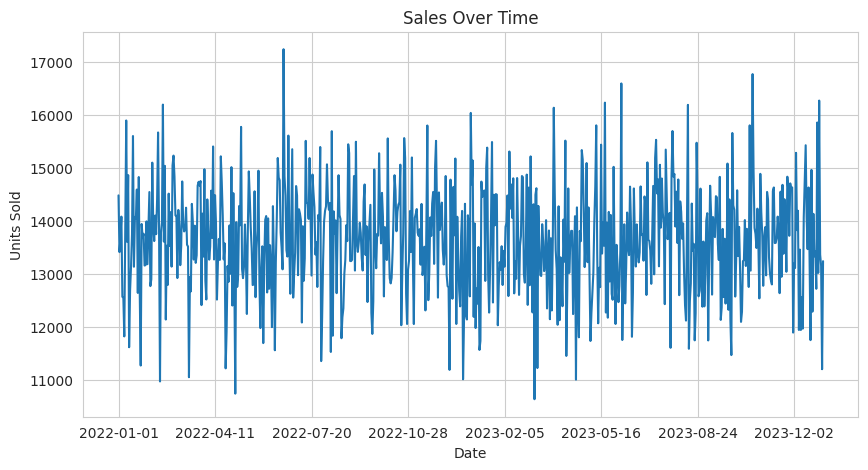

In [ ]:
sales_time = df.groupby("Date")["Units Sold"].sum()

plt.figure(figsize=(10,5))
sales_time.plot()
plt.title("Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.show()

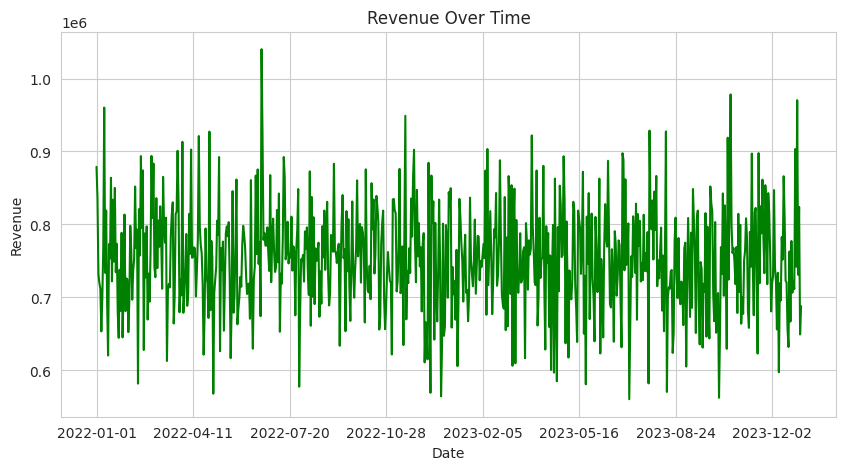

In [ ]:
revenue_time = df.groupby("Date")["Revenue"].sum()

plt.figure(figsize=(10,5))
revenue_time.plot(color="green")
plt.title("Revenue Over Time")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.show()

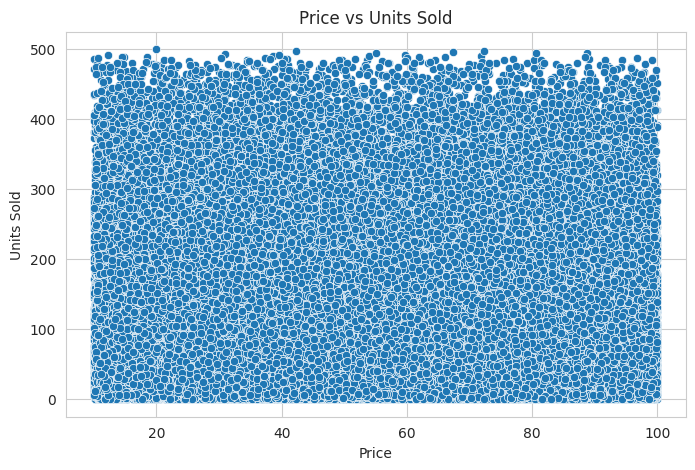

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="Price", y="Units Sold", data=df)
plt.title("Price vs Units Sold")
plt.show()

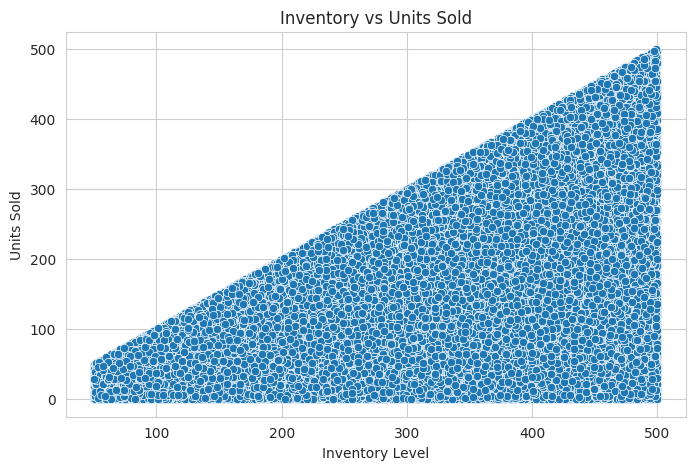

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="Inventory Level", y="Units Sold", data=df)
plt.title("Inventory vs Units Sold")
plt.show()

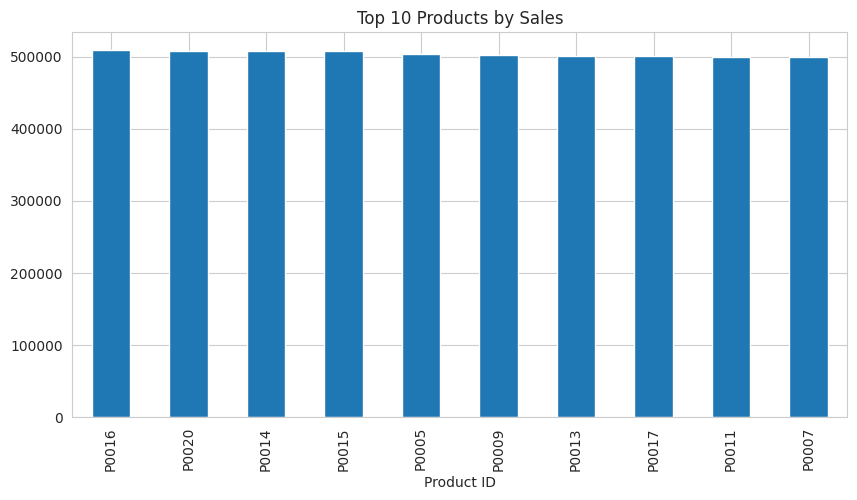

In [ ]:
product_sales = df.groupby("Product ID")["Units Sold"].sum()

product_sales.sort_values(ascending=False).head(10).plot(kind="bar", figsize=(10,5))
plt.title("Top 10 Products by Sales")
plt.show()

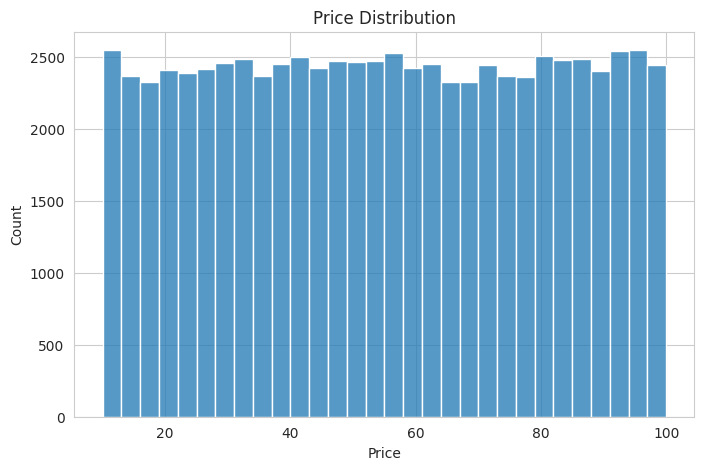

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["Price"], bins=30)
plt.title("Price Distribution")
plt.show()

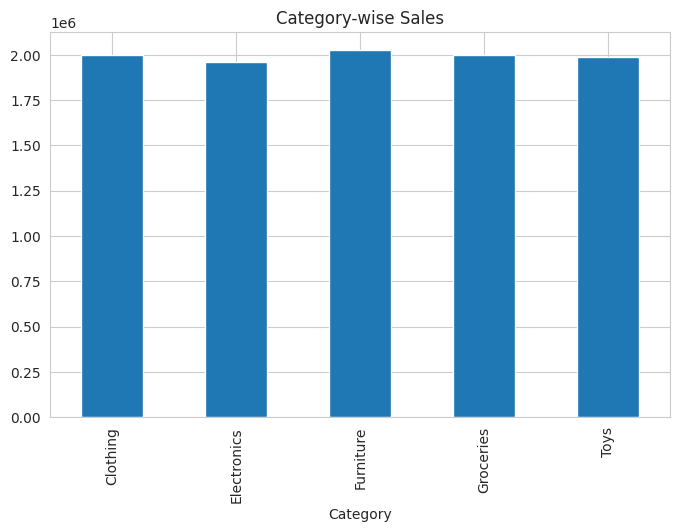

In [ ]:
category_sales = df.groupby("Category")["Units Sold"].sum()

category_sales.plot(kind="bar", figsize=(8,5))
plt.title("Category-wise Sales")
plt.show()

In [ ]:
df["Demand Segment"] = pd.qcut(df["Units Sold"], q=3, labels=["Low", "Medium", "High"])

df["Price Segment"] = pd.qcut(df["Price"], q=3, labels=["Low Price", "Medium Price", "High Price"])